## The main objective of this project is to predict if a customer will leave the telecommunications company based on contract details, including contract type, subscribed services, payment method, tenure and associated charges

# Importing the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Importing the dataset

In [2]:
dataset = pd.read_csv("Telco-Customer-Churn.csv")

In [3]:
print(dataset)

      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DSL             No  ...   
1        

## We can see above the structure of the dataset. It presents information regarding the contracts of 7043 customers, and it has 21 variables.

## The next step of the project is Exploratory Data Analysis (EDA) where I will check the variable types, if the dataset has null values, the classes of the target variable. I will also check the outliers and analyze if the removal is necessary or not. During this step of the project I will check the relationship between a few independent variables and the independent variable, the correlations between variables using a heatmap and a few conclussions of EDA.

# Checking variables types

In [4]:
print(dataset.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


## The variable "TotalCharges" appears as a variable of class "object". Therefore, it will be transformed into a numerical variable.

In [5]:
dataset['TotalCharges'] = pd.to_numeric(dataset['TotalCharges'], errors='coerce')

## The variable "SeniorCitizen" is a binary variable but in the dataset it is initially considered a numerical variable. In this case, it will be transformed into a categorical variable

In [6]:
dataset['SeniorCitizen'] = dataset['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

# Checking null values

In [7]:
print(dataset.isnull().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


## The dataset has 11 null values in the column "TotalCharges". They will be removed from the dataset since the elimination of so few lines does not affect the analysis. Then indexes will be reseted.

In [8]:
dataset = dataset.dropna(subset=['TotalCharges'])
dataset = dataset.reset_index(drop=True)

# Checking the distribution of the independent variable

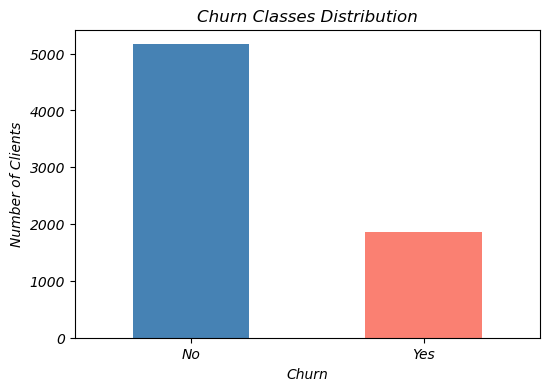

In [9]:
class_counts = dataset["Churn"].value_counts()
plt.figure(figsize = (6, 4))
class_counts.plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Churn Classes Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Clients')
plt.xticks(rotation=0)
plt.show()

In [10]:
print(dataset['Churn'].value_counts())
print(dataset['Churn'].value_counts(normalize=True))

Churn
No     5163
Yes    1869
Name: count, dtype: int64
Churn
No     0.734215
Yes    0.265785
Name: proportion, dtype: float64


## The graph shows that the class "No" has 5174 clients, meaning approximatively 73.46% of the total number of customers stayed with the company in the last month.

# Numerical variables analysis

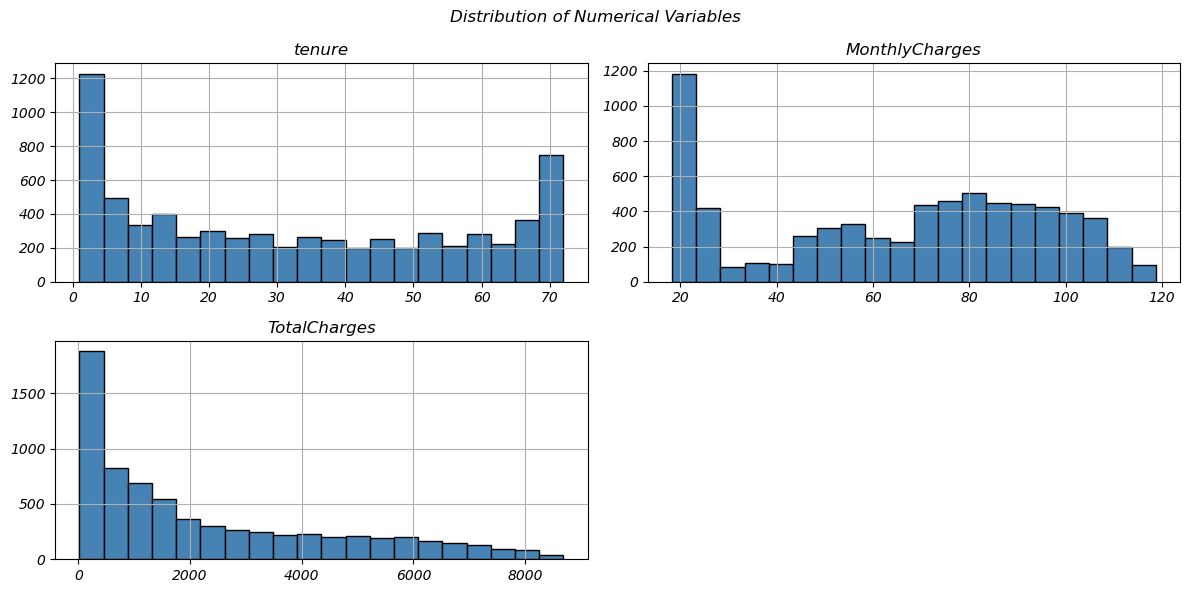

In [11]:
numeric_cols = dataset.select_dtypes(include=['int64', 'float64']).columns
dataset[numeric_cols].hist(figsize=(12, 6), bins=20, color='steelblue', edgecolor='black')
plt.suptitle('Distribution of Numerical Variables')
plt.tight_layout()
plt.show()

## The first graph shows that there are over 1000 new customers since the last month and almost 800 customers that are in the company for 70 months. The second graph shows how much money the customers are charged monthly, and we can see that most of them spend around 20 USD. There is also a large group of people who pay between 60 USD and 120 USD. The third graph presents the total charges of the customers, and we can see that most of them paid in total between 0 and 2000 USD and very few customers paid around 8000 USD during their contract.

# Categorical variables analysis

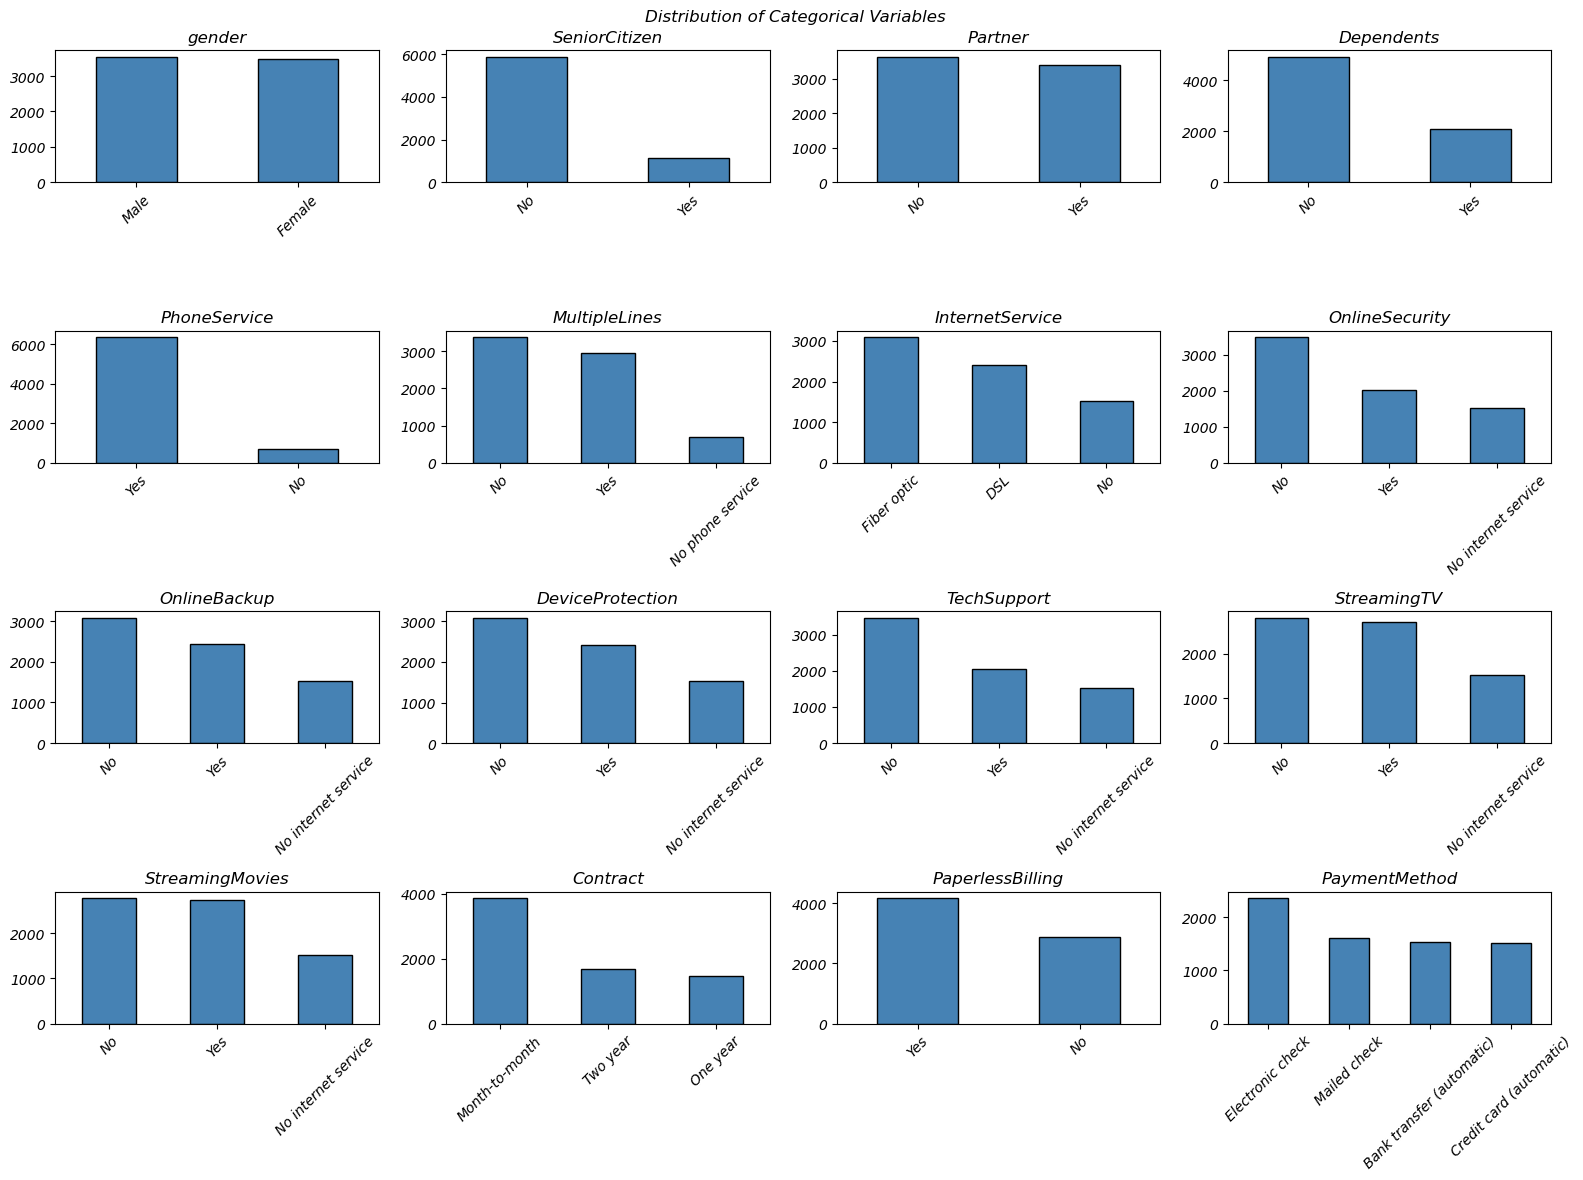

In [12]:
# Analiza variabilelor categoriale
categorical_cols = dataset.select_dtypes(include='object').columns
categorical_cols = categorical_cols.drop(['customerID', 'Churn'])

fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    dataset[col].value_counts().plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Distribution of Categorical Variables')
plt.tight_layout()
plt.show()

## The 16 graphs above show how the customers are distributed based on the categorical variables. There is an equal number of men and women, most of them are not senior citizens and most of them do not have a lot of benefits from their contract, like Multiple Lines, Online Security, Tech Support, Device Protection, Online Backup. Almost 4000 customers have a month-to-month contract.

# Outliers

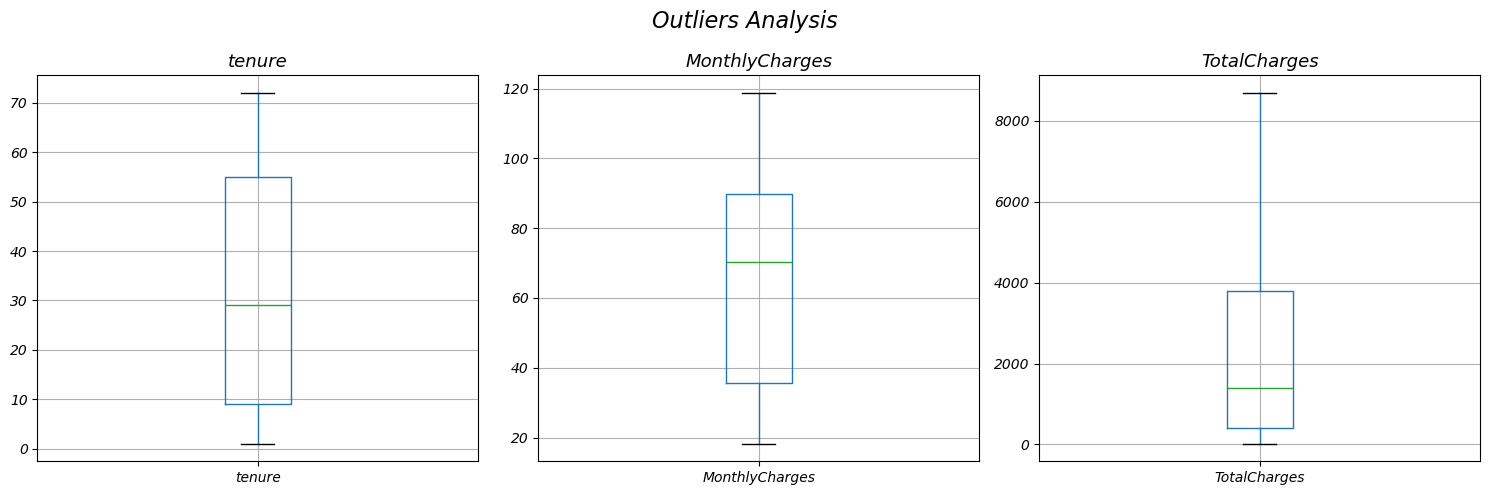

In [13]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))

for i, col in enumerate(numeric_cols):
    dataset.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col, fontsize=13)

plt.suptitle('Outliers Analysis', fontsize=16)
plt.tight_layout()
plt.show()

## The boxplots show no outliers in the numerical variables.

# Relationship between numerical variables and target variable

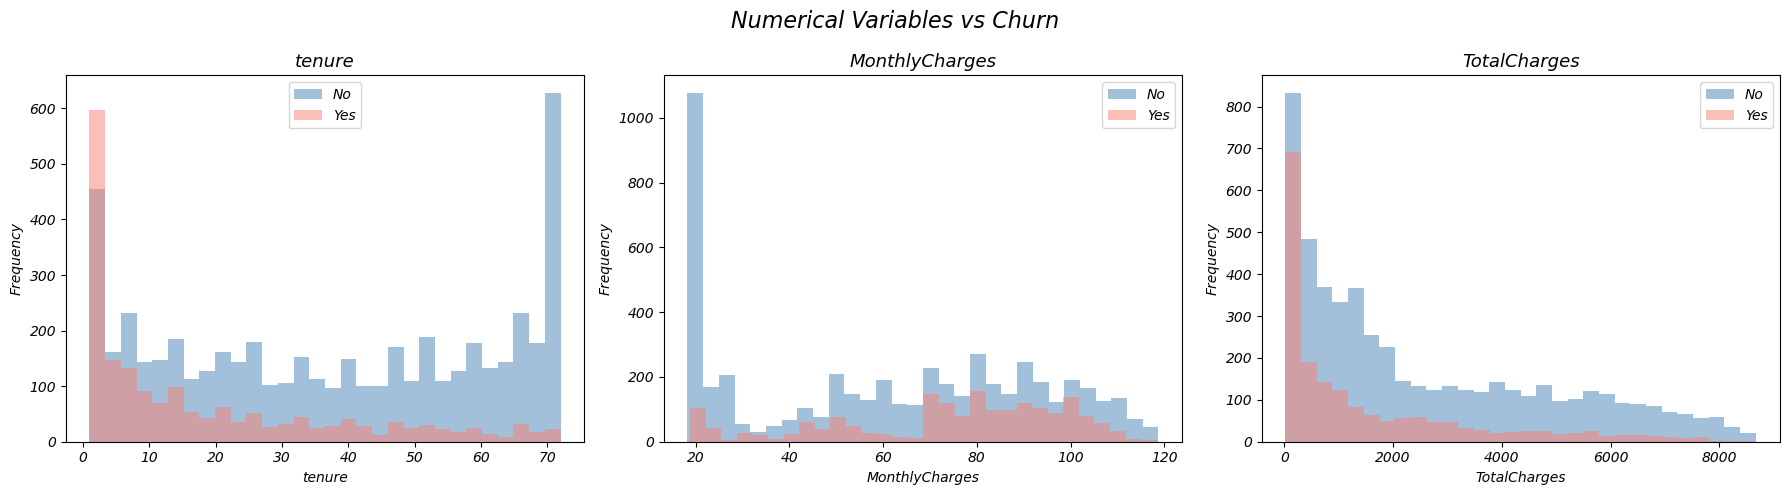

In [14]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

for i, col in enumerate(numeric_cols):
    dataset[dataset['Churn'] == 'No'][col].plot(kind='hist', ax=axes[i], alpha=0.5, label='No', bins=30, color='steelblue')
    dataset[dataset['Churn'] == 'Yes'][col].plot(kind='hist', ax=axes[i], alpha=0.5, label='Yes', bins=30, color='salmon')
    axes[i].set_title(col, fontsize=13)
    axes[i].set_xlabel(col)
    axes[i].legend()

plt.suptitle('Numerical Variables vs Churn', fontsize=16)
plt.tight_layout()
plt.show()

## The first graph shows that the most customers leave the company after the first 10 months. The second graph shows that the customer tend to leave because of high monthly charges. When we talk about total charges, we can see from the graph that very few people that stayed more tend to leave for another telecommunications company.

# Relationship between categorical variables and target variable

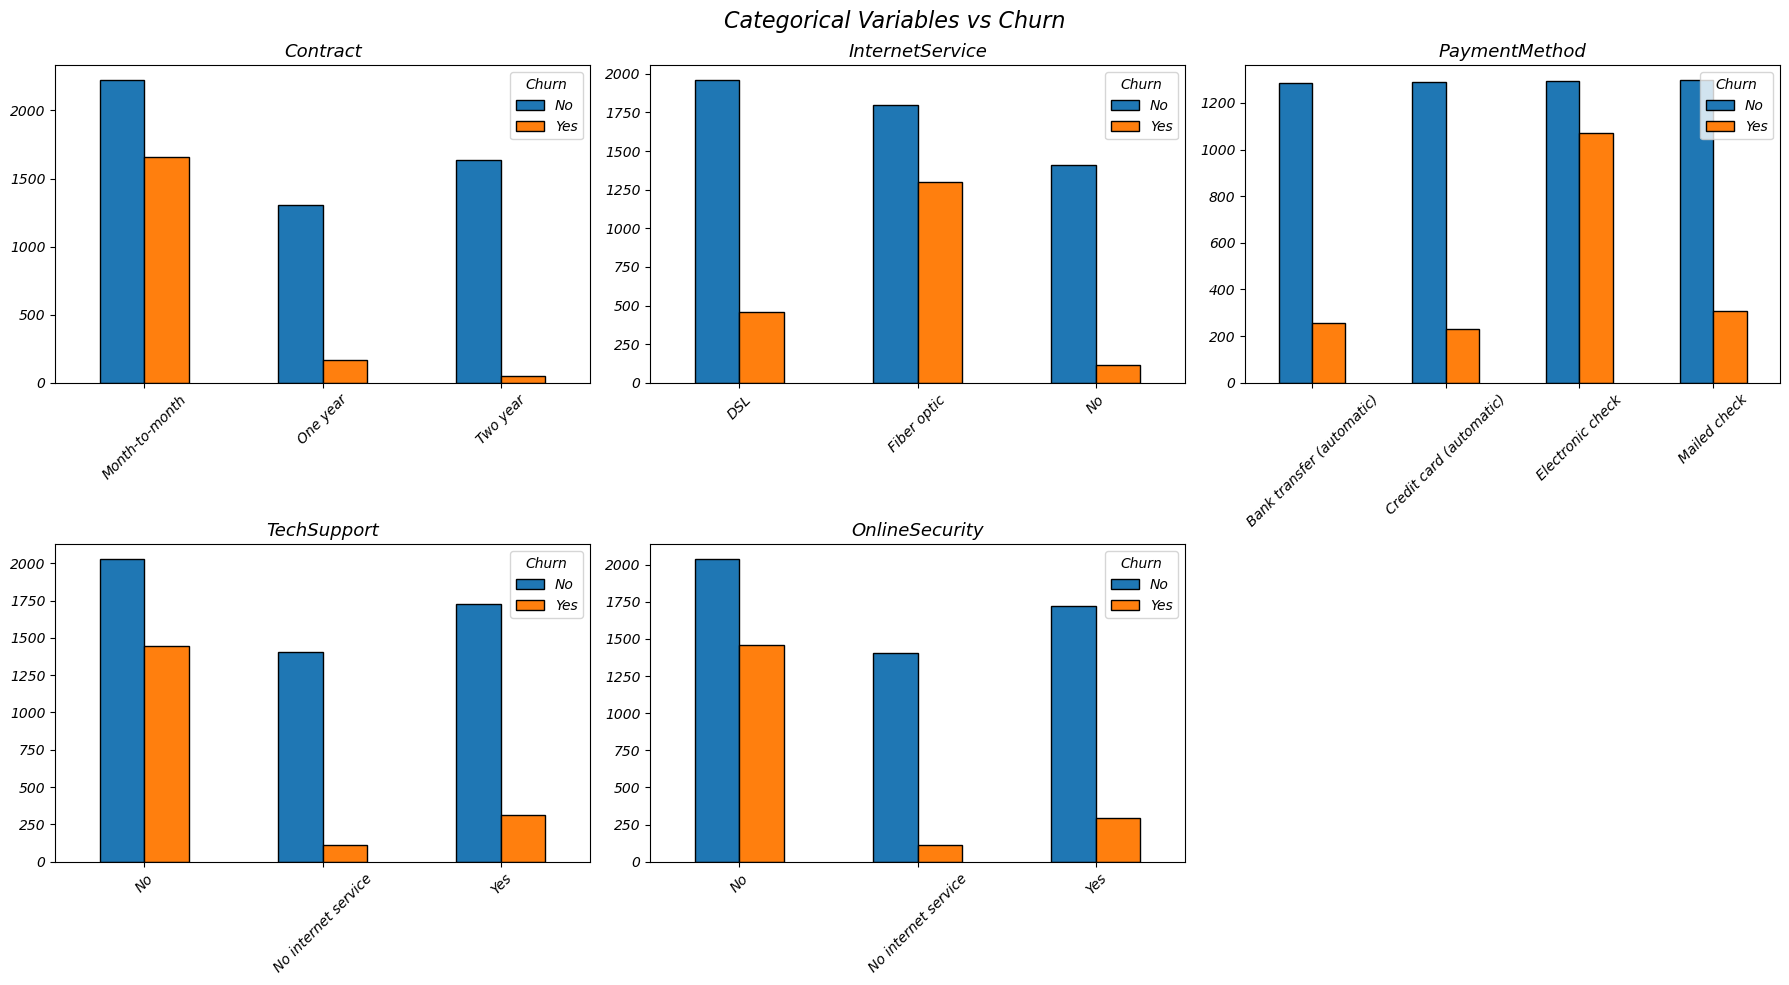

In [15]:
cols_to_plot = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport', 'OnlineSecurity']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    dataset.groupby([col, 'Churn']).size().unstack().plot(kind='bar', ax=axes[i], edgecolor='black')
    axes[i].set_title(col, fontsize=13)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

axes[-1].set_visible(False)
plt.suptitle('Categorical Variables vs Churn', fontsize=16)
plt.tight_layout()
plt.show()

## Most people remain customers of this company despite their contract duration, but most customers that leave have month-to-month contracts (approximately 1500). People that have internet service through fiber optic, pay through electronic check and do not have the tech support and online security options included in their contracts tend to leave more than the other categories, but most customers remain in this company.

# Correlations between numerical variables

In [16]:
pip install phik

Note: you may need to restart the kernel to use updated packages.


interval columns not set, guessing: ['tenure', 'MonthlyCharges', 'TotalCharges']


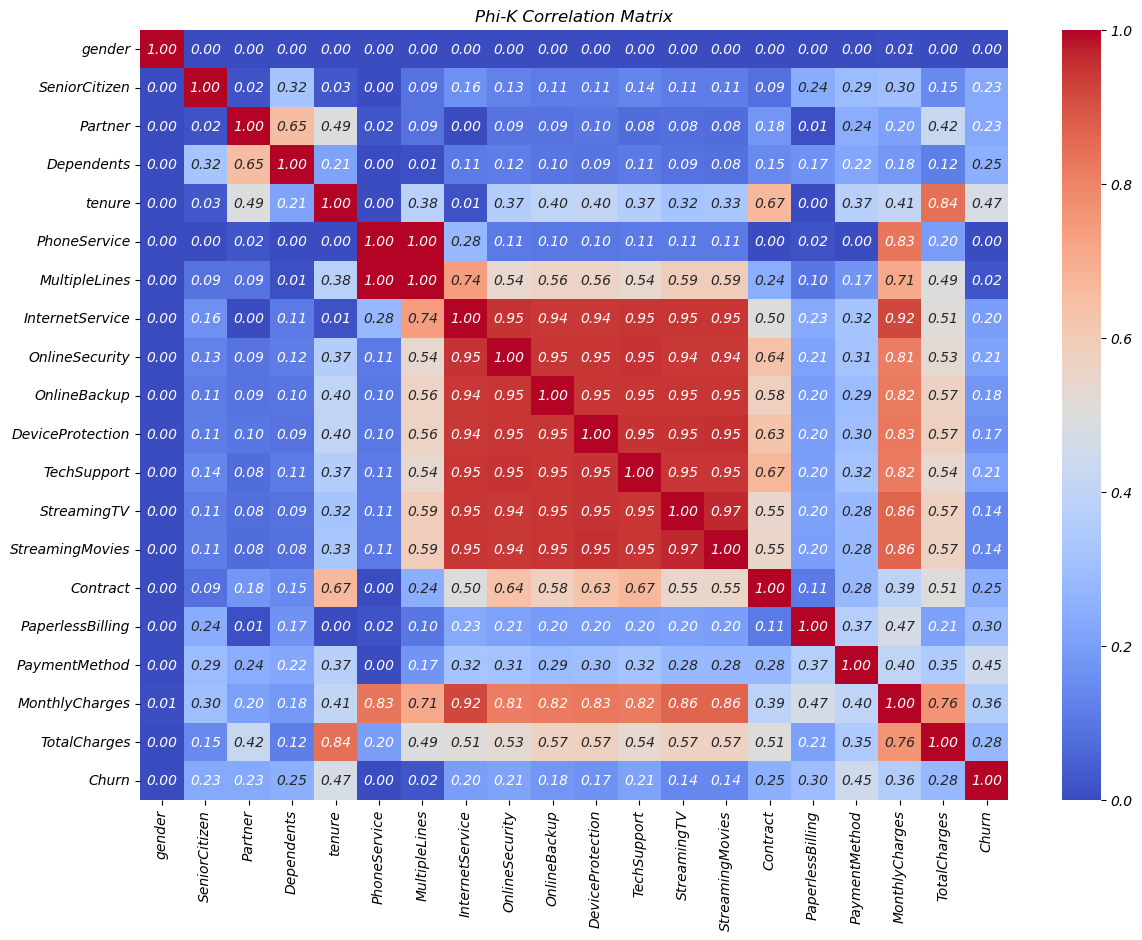

In [17]:
import phik
import seaborn as sns

dataset_no_id = dataset.drop(columns = ["customerID"])
corr_matrix = dataset_no_id.phik_matrix()
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Phi-K Correlation Matrix')
plt.show()

## This graph shows the correlation coefficients between all the variables in the dataset, excluding 'customerID' which is not relevant for our analysis. This heatmap uses the Phi-K (φk) correlation coefficient, which measures the strength of the relationship between all variable typeswith values ranging from 0 to 1.
## We can see from the heatmap that there is a moderate correlation between the payment method, how long the customers have had contract with this company and the monthly charges and the customers leaving the company.
## It's also visible that there is no correlation between the customer's gender and the other variables in the dataset.
## There is a very strong correlation between the contract services (the value of the coefficient Phi-K is greater than 0.9).
## There is also a strong correlation between the services offered by the contract and monthly charges for every customer (coefficient Phi-K value is greater than 0.7).

# Conclusions of EDA

## After analyzing the dataset, there are a few trends that can be observed:
## 1. Customers with month-to-month contracts have a higher rate to leave than those with one or two-year contracts.
## 2. Looking at the graph that shows the relationship between tenure and churn, it is that the customers tend to leave the company early in the contract. The customers that stayed a longer period remain with the company.
## 3. People that have Internet Service but do not have benefits such as Online Security or Tech Support are more liable to churning.
## 4. The correlation matrix demonstrates that there is no correlation between churn and the customer's gender. In fact, the gender is completely irrelevant in relation with any other variable.

## The next part of the project is preprocessing the dataset. Firstly, the dataset will be separated in 2 parts, one that has only independent variables in a matrix of features and the other one which contains only the target variable. Since we already know what categorical variables we have and how their structure is, we can encode the categorical variables. After that, the whole dataset will be split into a training set and test set, will apply feature scaling. The most important step of this part is applying Machine Learning and Deep Learning models to make predictions on whether a customer will keep the contract with this telecommunication company or if he will leave to another company. We will analyze the metrics these models get, will check what are the most important features from the dataset for each model and will compare all the models to see which is the best model.

In [18]:
X = dataset.drop(columns = ["customerID", "Churn"])
y = dataset["Churn"]

## Encoding the target variable

In [19]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

## Encoding the independent binary variables

In [20]:
X["gender"] = X["gender"].map({"Female": 0, "Male": 1})

binary_mapping = {
    "Yes": 1,
    "No": 0
}

binary_variables = ["SeniorCitizen", "Partner", "Dependents", "PhoneService", "PaperlessBilling"]

# Encoded the variables 0, 1, 2, 3, 5, 15

for var in binary_variables:
    X[var] = X[var].map(binary_mapping)

## Encoding variables with multiple categories

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers = [('encoder', OneHotEncoder(), [6, 7, 8, 9, 10, 11, 12, 13, 14, 16])], remainder = "passthrough")
X = ct.fit_transform(X)

In [22]:
print(X)

[[0.0000e+00 1.0000e+00 0.0000e+00 ... 1.0000e+00 2.9850e+01 2.9850e+01]
 [1.0000e+00 0.0000e+00 0.0000e+00 ... 0.0000e+00 5.6950e+01 1.8895e+03]
 [1.0000e+00 0.0000e+00 0.0000e+00 ... 1.0000e+00 5.3850e+01 1.0815e+02]
 ...
 [0.0000e+00 1.0000e+00 0.0000e+00 ... 1.0000e+00 2.9600e+01 3.4645e+02]
 [0.0000e+00 0.0000e+00 1.0000e+00 ... 1.0000e+00 7.4400e+01 3.0660e+02]
 [1.0000e+00 0.0000e+00 0.0000e+00 ... 1.0000e+00 1.0565e+02 6.8445e+03]]


# Splitting the dataset into Train/Test split

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Data balancing (it is necessary because approximately 73% of customers are in "No" category)

In [24]:
from imblearn.combine import SMOTETomek

balancing = SMOTETomek(random_state = 42)
X_train_resampled, y_train_resampled = balancing.fit_resample(X_train, y_train)

# Feature scaling

In [25]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_resampled = sc.fit_transform(X_train_resampled)
X_test = sc.transform(X_test)

# Machine Learning Models and Metrics

In [26]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_auc_score, average_precision_score, f1_score
from sklearn.model_selection import cross_val_score

In [27]:
def evaluate_model(name, classifier, X_train_resampled, y_train_resampled, X_test, y_test):
    print(f"\n--- {name} ---\n")

    accuracies = cross_val_score(estimator = classifier, X = X_train_resampled, y = y_train_resampled, cv = 10)
    print(f"CV Accuracy: {accuracies.mean() * 100: .2f}%")
    classifier.fit(X_train_resampled, y_train_resampled)
    y_pred = classifier.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix:")
    print(cm)
    print(f"\nTest Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print(f"AUC-ROC: {roc_auc_score(y_test, y_pred):.4f}")
    print(f"Average Precision: {average_precision_score(y_test, y_pred):.4f}")

    return y_pred

## 1. Decision Tree

In [28]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(criterion = 'entropy', random_state = 42)
dt_pred = evaluate_model("Decision Tree", dt, X_train_resampled, y_train_resampled, X_test, y_test)


--- Decision Tree ---

CV Accuracy:  82.45%

Confusion Matrix:
[[813 220]
 [160 214]]

Test Accuracy: 0.7299

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.79      0.81      1033
           1       0.49      0.57      0.53       374

    accuracy                           0.73      1407
   macro avg       0.66      0.68      0.67      1407
weighted avg       0.74      0.73      0.74      1407

AUC-ROC: 0.6796
Average Precision: 0.3959


## 2. Random Forest

In [29]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators = 10, criterion = 'entropy', random_state = 42)
rf_pred = evaluate_model("Random Forest", rf, X_train_resampled, y_train_resampled, X_test, y_test)


--- Random Forest ---

CV Accuracy:  85.78%

Confusion Matrix:
[[912 121]
 [188 186]]

Test Accuracy: 0.7804

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.88      0.86      1033
           1       0.61      0.50      0.55       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407

AUC-ROC: 0.6901
Average Precision: 0.4349


## 3. XGBoost

In [30]:
from xgboost import XGBClassifier
xgb = XGBClassifier(random_state = 42, eval_metric='logloss')
xgb_pred = evaluate_model("XGBoost", xgb, X_train_resampled, y_train_resampled, X_test, y_test)


--- XGBoost ---

CV Accuracy:  85.59%

Confusion Matrix:
[[880 153]
 [165 209]]

Test Accuracy: 0.7740

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.85      0.85      1033
           1       0.58      0.56      0.57       374

    accuracy                           0.77      1407
   macro avg       0.71      0.71      0.71      1407
weighted avg       0.77      0.77      0.77      1407

AUC-ROC: 0.7054
Average Precision: 0.4399


## 4. CatBoost

In [31]:
from catboost import CatBoostClassifier
cb = CatBoostClassifier(random_state = 42, verbose=0)
cb_pred = evaluate_model("CatBoost", cb, X_train_resampled, y_train_resampled, X_test, y_test)


--- CatBoost ---

CV Accuracy:  86.62%

Confusion Matrix:
[[898 135]
 [165 209]]

Test Accuracy: 0.7868

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.87      0.86      1033
           1       0.61      0.56      0.58       374

    accuracy                           0.79      1407
   macro avg       0.73      0.71      0.72      1407
weighted avg       0.78      0.79      0.78      1407

AUC-ROC: 0.7141
Average Precision: 0.4568


# Comparing metrics for all models

In [32]:
def get_metrics(name, y_true, y_pred):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred, pos_label=1),
        'AUC-ROC': roc_auc_score(y_true, y_pred)
    }

results = [
    get_metrics("Decision Tree", y_test, dt_pred),
    get_metrics("Random Forest", y_test, rf_pred),
    get_metrics("XGBoost", y_test, xgb_pred),
    get_metrics("CatBoost", y_test, cb_pred),
]

pd.DataFrame(results)

,Model,Accuracy,F1-Score,AUC-ROC
0,Decision Tree,0.729922,0.529703,0.679610
1,Random Forest,0.780384,0.546256,0.690096
2,XGBoost,0.773987,0.567935,0.705356
3,CatBoost,0.786780,0.582173,0.714068


## On this dataset, there are no major differences between the machine learning models. We can observe from this table that the CatBoost model is the one that takes the best decisions, approximately 78.68%. But the accuracy is not the only metric we should check, because it can be deceptive. When we look at the F1-Score column, it shows that almost half of our "alerts" are wrong, meaning there are customers that really want to leave but the models cannot help us detect this on time and there are customers that don't want to end the contract but the models inform us that they want to leave. The AUC-ROC metric presents to us that all the models have a moderate capacity of distinguishing between the customers who leave and the customers who remain, with values between 0.679 and 0.714.

# Features importance

In [33]:
feature_names = ct.get_feature_names_out()

models = {
    "Decision Tree": dt,
    "Random Forest": rf,
    "XGBoost": xgb,
    "CatBoost": cb, 
}

for name, model in models.items():
    importance = pd.Series(
        model.feature_importances_,
        index=feature_names
    ).sort_values(ascending=False)

    print(f"\n{name}")
    print(importance.head(10))


Decision Tree
encoder__Contract_Month-to-month           0.268820
remainder__MonthlyCharges                  0.123666
remainder__TotalCharges                    0.119889
encoder__OnlineSecurity_No                 0.096017
remainder__tenure                          0.078361
encoder__PaymentMethod_Electronic check    0.059440
encoder__InternetService_Fiber optic       0.023683
remainder__gender                          0.022575
remainder__PaperlessBilling                0.020890
encoder__TechSupport_No                    0.017616
dtype: float64

Random Forest
remainder__TotalCharges                    0.121227
encoder__TechSupport_No                    0.088859
remainder__MonthlyCharges                  0.087904
remainder__tenure                          0.076474
encoder__OnlineSecurity_No                 0.059837
encoder__Contract_Month-to-month           0.055478
encoder__Contract_Two year                 0.042626
encoder__PaymentMethod_Electronic check    0.038131
encoder__Contract_O

## We can observ that the Decision Tree, Random Forest and XGBoost models have almost the same most important risk factors for the customers choosing to leave the company, for example the month-to-month contracts, monthly charges, the absence of online security. Instead, CatBoost is almost completely different, and it says that the most customers end or want to end their contracts because of their gender, the fact that they have a partner, the tenure and the fact that they have a partner. This analysis shows that it is important to test more models before taking an important business decision as what we should do to keep most of our customers.

# Final Conclusions

## The main objective of this project was to predict customer churn based on contract details. The obtained results show that contract type is the most important factor that can lead to customer churning. There are also other significant factors that can make the customers leave the company, such as monthly charges, service adoption and tenure.
## Given this insight, the company should concentrate more on building customer loyalty to keep the newest customers for a longer time by offering them contracts on longer terms. Also, the company could grant discounts for customers in the first months.
## In this project 4 Machine Learning models were tested: CatBoost, XGBoost, Decision Trees and Random Forest. Out of all, CatBoost obtained the best overall performance, with an accuracy of 78.68% and an AUC-ROC score of 0.714. Though the differences between the metrics of all models is small.
## We can also notice that the F1-score is moderate for all models (between 0.53 and 0.58), meaning a significant part of the customers that could leave the company are still misclassified.
## While Decision Tree, Random Forest and XGBoost use almost the same features to predict customer churn, CatBoost identified a very different set of features that could be important in predicting if a customer stays or leaves. This means that no single model should be trusted in taking business decisions. If there are more models tested, we can identify the most important problems and take the best decisions for our customers.